<a href="https://colab.research.google.com/github/Akanksha-s23/Cancer-Prediction/blob/main/Cancer_Prediction_(2_types_Benign_%26_Malignant).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Important Libraries**

In [28]:

# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



# **Loading Dataset**

In [29]:

# 2. LOAD DATA

url = "https://github.com/YBIFoundation/Dataset/raw/main/Cancer.csv"
df = pd.read_csv(url)

In [30]:
# Show basic info
print(df.head())
print(df.info())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [31]:

if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)

In [32]:
# Convert diagnosis to numeric
# M = malignant (1), B = benign (0)
# Clean 'diagnosis' column before mapping to handle potential inconsistencies (e.g., casing, spaces)
df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper().map({'M': 1, 'B': 0})

# Drop rows where 'diagnosis' is NaN (due to values other than M or B)
df.dropna(subset=['diagnosis'], inplace=True)

In [33]:
# 3. FEATURES & TARGET

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [34]:
# 4. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:

# 5. SCALING

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Model Training**

In [36]:
# 6. MODEL TRAINING

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# **Model Accuracy**

In [38]:
# 8. EVALUATION
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9736842105263158

Confusion Matrix:
 [[70  1]
 [ 2 41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



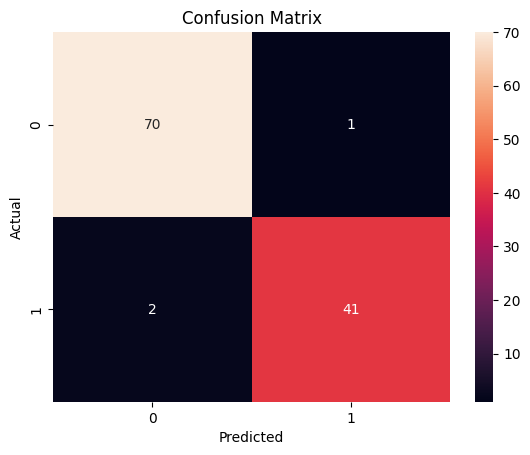

In [39]:
# 9. CONFUSION MATRIX GRAPH

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()